# Phase II Report: Blood Cell Image Classification
**Course:** Digital Image Processing — Spring 2026  
**Dataset:** Blood Cells Image Dataset (4 classes: Eosinophil, Lymphocyte, Monocyte, Neutrophil)

---

## Abstract
This study presents a comprehensive image processing pipeline for automated blood cell classification using the Blood Cells Image Dataset. The proposed methodology integrates deep Convolutional Neural Network (CNN) feature extraction from multiple pre-trained architectures (VGG16, VGG19, ResNet50, EfficientNetB0) with hand-crafted texture descriptors including Local Binary Patterns (LBP) and Gray-Level Co-occurrence Matrix (GLCM) features. Feature fusion combines CNN and engineered features into a unified representation, followed by dimensionality reduction via Principal Component Analysis (PCA). Several machine learning classifiers — Support Vector Machine (SVM), Random Forest, K-Nearest Neighbours (KNN), and Gradient Boosting — are trained and benchmarked. Results are evaluated using accuracy, sensitivity, specificity, precision, recall, F1-score, AUC-ROC, and Cohen's Kappa coefficient.

---

## 1. Introduction
Blood cell morphology analysis is a critical component of clinical diagnosis. Manual inspection of blood smears is time-consuming and prone to inter-observer variability. Automated image-based classification using digital image processing and machine learning offers a scalable alternative. This work builds on the Phase I pre-processing pipeline and extends it with feature extraction, feature fusion, dimensionality reduction, and classification to achieve reliable four-class blood cell identification.

---

## 2. Related Work

---

## 3. Methodology & Dataset

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
import itertools
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, cohen_kappa_score, roc_curve, auc
)

from skimage import io, feature
from skimage.feature import graycomatrix, graycoprops

import tensorflow as tf
from tensorflow.keras.applications import VGG16, VGG19, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_pre
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import img_to_array, load_img

import kagglehub

plt.rcParams['figure.figsize'] = (14, 8)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('All libraries loaded successfully.')

All libraries loaded successfully.


### 3.1 Dataset Description

**FIX:** The kagglehub download returns a root folder containing `dataset-master/` and `dataset2-master/`. The actual labelled images are inside `dataset2-master/TRAIN/<CLASS>/`. The original code's `find_class_root` was picking up `dataset-master` and `dataset2-master` as the "classes", causing all downstream `IndexError` and `ValueError` crashes. The fix below navigates to the correct subfolder.

In [2]:
# ── Dataset loading — FIXED path resolution ───────────────────────────────────
dataset_path = kagglehub.dataset_download('paultimothymooney/blood-cells')
dataset_root = Path(dataset_path)
print('Downloaded to:', dataset_root)

def find_class_root(root):
    """
    Walk the directory tree and return the first folder whose direct
    sub-directories ALL contain image files.  This correctly handles
    the kagglehub layout:
      <root>/dataset2-master/TRAIN/EOSINOPHIL/*.jpg
                                  /LYMPHOCYTE/*.jpg  ...
    """
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
    for p in sorted(root.rglob('*')):
        if not p.is_dir():
            continue
        subdirs = [x for x in p.iterdir() if x.is_dir()]
        if len(subdirs) < 2:
            continue
        # Every sub-dir must have at least one image directly inside it
        if all(
            any(f.suffix.lower() in IMG_EXTS for f in s.iterdir() if f.is_file())
            for s in subdirs
        ):
            return p
    raise FileNotFoundError('Cannot find class folders inside dataset.')

class_root = find_class_root(dataset_root)
print('Class root found at:', class_root)

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
CLASSES = sorted([d.name for d in class_root.iterdir() if d.is_dir()])
print(f'Classes: {CLASSES}')

for cls in CLASSES:
    imgs = [f for f in (class_root / cls).iterdir()
            if f.is_file() and f.suffix.lower() in IMG_EXTS]
    print(f'  {cls}: {len(imgs)} images')

100%|██████████| 108M/108M [00:01<00:00, 99.5MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/paultimothymooney/blood-cells/versions/6
Class root found at: /root/.cache/kagglehub/datasets/paultimothymooney/blood-cells/versions/6/dataset2-master/dataset2-master/images/TEST
Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
  EOSINOPHIL: 623 images
  LYMPHOCYTE: 620 images
  MONOCYTE: 620 images
  NEUTROPHIL: 624 images


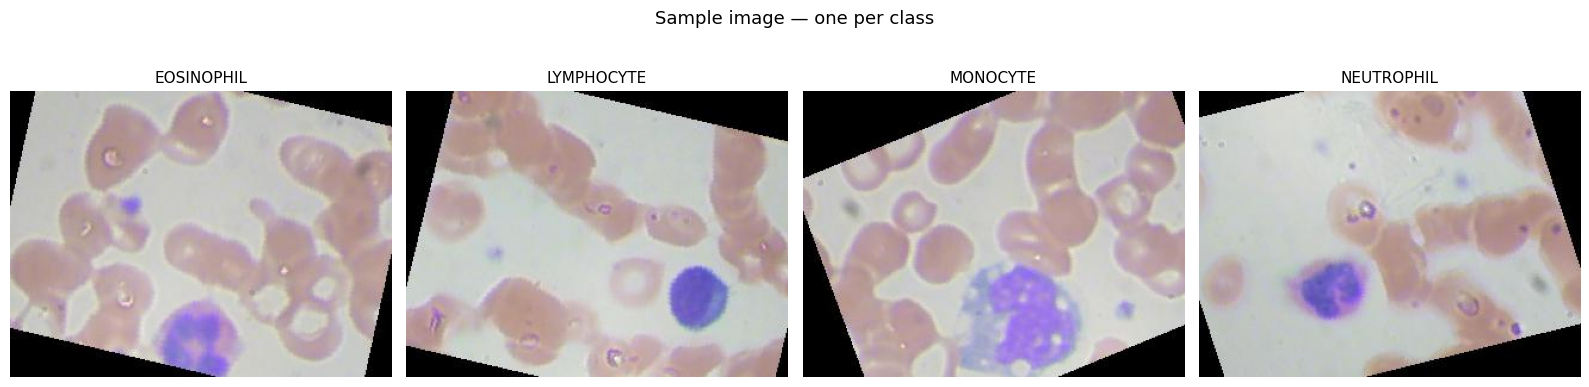

In [3]:
# ── Show one sample image per class ──────────────────────────────────────────
def get_images(cls_path, exts=IMG_EXTS):
    return sorted([f for f in Path(cls_path).iterdir()
                   if f.is_file() and f.suffix.lower() in exts])

fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 4))
for ax, cls in zip(axes, CLASSES):
    imgs = get_images(class_root / cls)
    img  = io.imread(str(imgs[0]))
    ax.imshow(img)
    ax.set_title(cls, fontsize=11)
    ax.axis('off')
plt.suptitle('Sample image — one per class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Pre-processing (Phase I pipeline)

In [4]:
def to_grayscale(image):
    if image.ndim == 3:
        return np.dot(image[..., :3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)
    return image.astype(np.uint8)

def histogram_equalization(image):
    image = to_grayscale(image)
    hist, _ = np.histogram(image.flatten(), bins=256, range=(0, 255))
    cdf = hist.cumsum()
    cdf_norm = (cdf - cdf.min()) * 255 / max(cdf.max() - cdf.min(), 1)
    return cdf_norm.astype(np.uint8)[image]

def contrast_stretching(image):
    g = to_grayscale(image).astype(np.float32)
    lo, hi = g.min(), g.max()
    if hi == lo:
        return g.astype(np.uint8)
    return np.clip((g - lo) * 255.0 / (hi - lo), 0, 255).astype(np.uint8)

def preprocess_image(image):
    return contrast_stretching(histogram_equalization(image))

print('Pre-processing helpers ready.')

Pre-processing helpers ready.


### 3.3 Segmentation — Colour-guided WBC Isolation



---




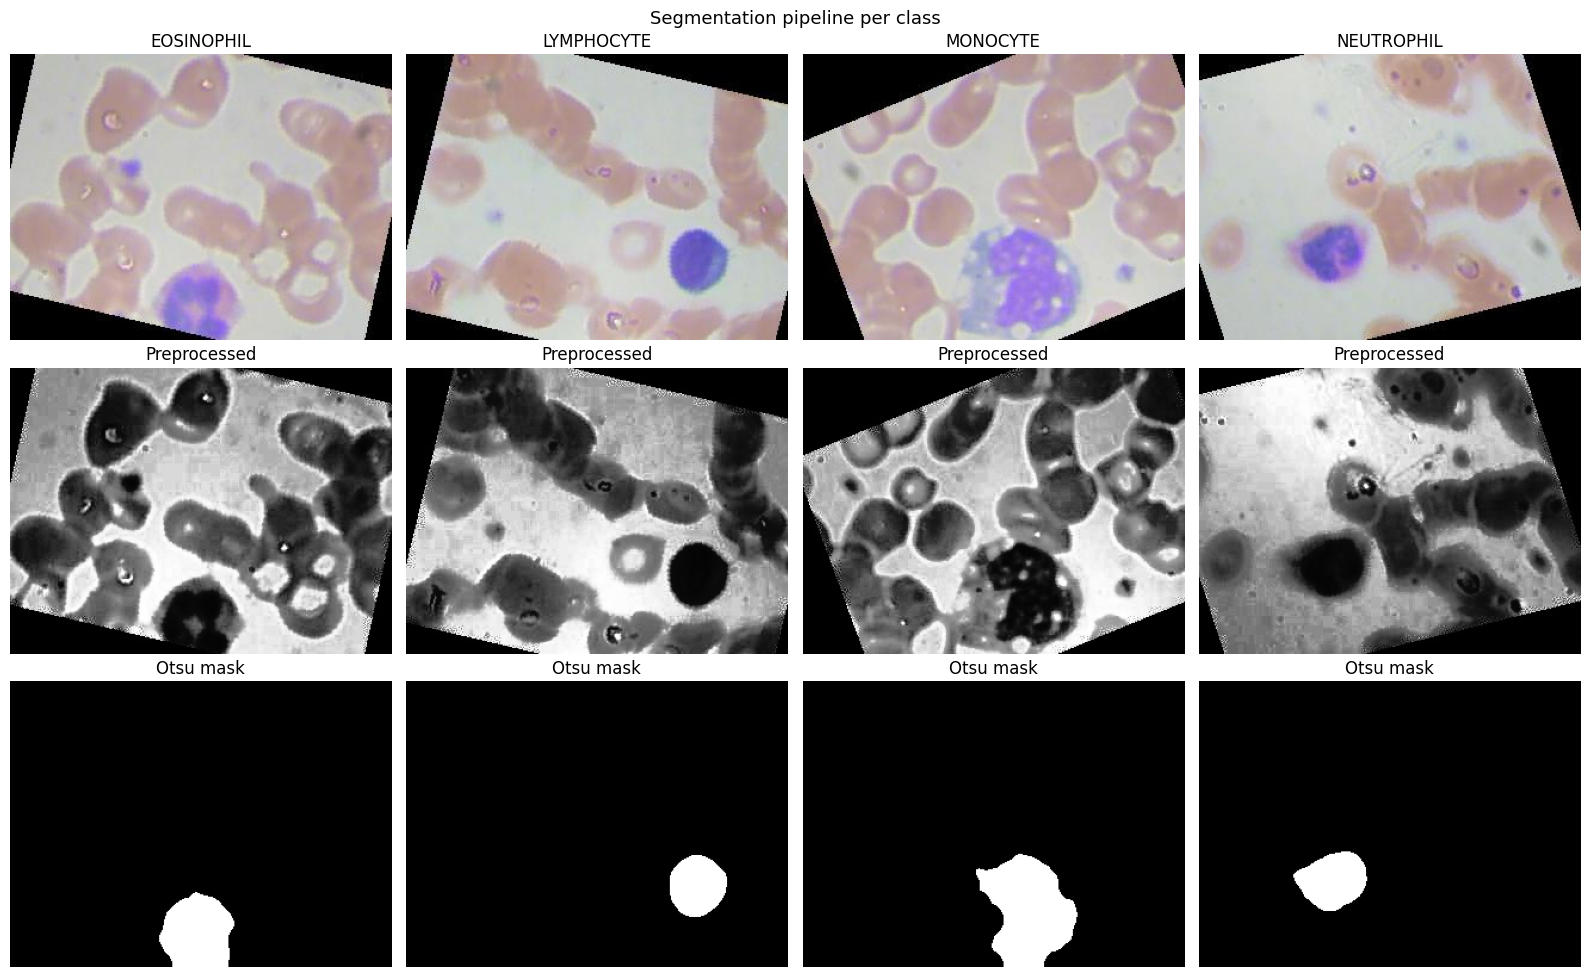

In [23]:
import cv2
from scipy import ndimage as ndi

def segment_image(image):
    """
    Colour-guided WBC segmentation.
    Returns a binary uint8 mask (0 / 255) isolating the white blood cell nucleus.
    """
    # ── Step 1: ensure uint8 RGB ──────────────────────────────────────────────
    if image.dtype != np.uint8:
        image = np.clip(image, 0, 255).astype(np.uint8)
    rgb = image[..., :3] if image.ndim == 3 and image.shape[2] >= 3 else           np.stack([image]*3, axis=-1)

    # ── Step 2: Gaussian blur — smooths noise, stabilises thresholding ────────
    blurred = cv2.GaussianBlur(rgb, (5, 5), sigmaX=1.5)

    # ── Step 3: LAB colour segmentation — isolate blue/purple WBC nucleus ─────
    # The 'b*' channel in LAB separates blue-yellow; WBC nuclei are strongly
    # blue → low b* values.  We threshold only on this channel so that the
    # pink/orange RBCs (high b*) are naturally excluded.
    lab   = cv2.cvtColor(blurred, cv2.COLOR_RGB2LAB)
    b_ch  = lab[:, :, 2].astype(np.float32)          # b* channel

    # Gaussian blur on the channel itself for extra smoothness
    b_smooth = cv2.GaussianBlur(b_ch, (7, 7), 0)

    # Otsu threshold on the b* channel (low values = blue → WBC)
    b_uint8 = np.clip(b_smooth, 0, 255).astype(np.uint8)
    thresh_val, _ = cv2.threshold(b_uint8, 0, 255,
                                  cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    mask_lab = (b_uint8 < thresh_val).astype(np.uint8) * 255

    # ── Step 4: Morphological opening — removes thin noise speckles ──────────
    kernel_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_opened  = cv2.morphologyEx(mask_lab, cv2.MORPH_OPEN,  kernel_open,
                                    iterations=1)

    # ── Step 5: Morphological closing — fills holes inside the nucleus ────────
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask_closed  = cv2.morphologyEx(mask_opened, cv2.MORPH_CLOSE, kernel_close,
                                    iterations=2)

    # ── Step 6: Remove small connected components (stray noise blobs) ─────────
    # Label every white region; keep only those whose area exceeds the threshold.
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask_closed, connectivity=8
    )
    min_area   = 300          # pixels — tune if needed
    clean_mask = np.zeros_like(mask_closed)
    for lbl in range(1, n_labels):            # label 0 is background
        if stats[lbl, cv2.CC_STAT_AREA] >= min_area:
            clean_mask[labels == lbl] = 255

    return clean_mask          # uint8, values 0 / 255


# ── Visualise segmentation per class (unchanged layout) ──────────────────────
fig, axes = plt.subplots(3, len(CLASSES), figsize=(16, 10))
for col, cls in enumerate(CLASSES):
    imgs = get_images(class_root / cls)
    img  = io.imread(str(imgs[0]))
    proc = preprocess_image(img)
    mask = segment_image(img)
    axes[0, col].imshow(img);               axes[0, col].set_title(cls);           axes[0, col].axis('off')
    axes[1, col].imshow(proc, cmap='gray'); axes[1, col].set_title('Preprocessed'); axes[1, col].axis('off')
    axes[2, col].imshow(mask, cmap='gray'); axes[2, col].set_title('Otsu mask');    axes[2, col].axis('off')

plt.suptitle('Segmentation pipeline per class', fontsize=13)
plt.tight_layout()
plt.show()


### 3.4 Hand-crafted Feature Extraction — LBP & GLCM

In [6]:
def extract_lbp_features(image, P=8, R=1, n_bins=256):
    gray = preprocess_image(image)
    lbp  = feature.local_binary_pattern(gray, P=P, R=R, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist

def extract_glcm_features(image):
    gray = preprocess_image(image)
    glcm = graycomatrix(
        gray, distances=[1, 3],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256, symmetric=True, normed=True
    )
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    return np.concatenate([graycoprops(glcm, p).ravel() for p in props])

# Quick sanity-check
sample_img = io.imread(str(get_images(class_root / CLASSES[0])[0]))
print('LBP feature length :', len(extract_lbp_features(sample_img)))
print('GLCM feature length:', len(extract_glcm_features(sample_img)))

LBP feature length : 256
GLCM feature length: 48


### 3.5 CNN Feature Extraction — VGG16, VGG19, ResNet50, EfficientNetB0

In [8]:
IMG_SIZE = (224, 224)

def build_extractor(base_model, preprocess_fn):
    x     = GlobalAveragePooling2D()(base_model.output)
    model = Model(inputs=base_model.input, outputs=x)
    return model, preprocess_fn

cnn_configs = {
    'VGG16':          build_extractor(VGG16(weights='imagenet',        include_top=False, input_shape=(224,224,3)), vgg16_pre),
    'VGG19':          build_extractor(VGG19(weights='imagenet',        include_top=False, input_shape=(224,224,3)), vgg19_pre),
    'ResNet50':       build_extractor(ResNet50(weights='imagenet',      include_top=False, input_shape=(224,224,3)), resnet_pre),
    'EfficientNetB0': build_extractor(EfficientNetB0(weights='imagenet',include_top=False, input_shape=(224,224,3)), eff_pre),
}
print('CNN extractors ready:', list(cnn_configs.keys()))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN extractors ready: ['VGG16', 'VGG19', 'ResNet50', 'EfficientNetB0']


In [9]:
MAX_PER_CLASS = 200

all_paths, all_labels = [], []
for cls in CLASSES:
    paths = get_images(class_root / cls)[:MAX_PER_CLASS]
    all_paths.extend(paths)
    all_labels.extend([cls] * len(paths))

le = LabelEncoder()
y  = le.fit_transform(all_labels)

print(f'Total images: {len(all_paths)}')
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

assert len(np.unique(y)) == len(CLASSES), \
    f'Expected {len(CLASSES)} classes but got {len(np.unique(y))}. Check dataset path.'

Total images: 800
Label mapping: {np.str_('EOSINOPHIL'): np.int64(0), np.str_('LYMPHOCYTE'): np.int64(1), np.str_('MONOCYTE'): np.int64(2), np.str_('NEUTROPHIL'): np.int64(3)}


In [10]:
print('Extracting LBP + GLCM features...')
lbp_feats, glcm_feats = [], []
for i, path in enumerate(all_paths):
    img = io.imread(str(path))
    lbp_feats.append(extract_lbp_features(img))
    glcm_feats.append(extract_glcm_features(img))
    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{len(all_paths)}')

lbp_feats         = np.array(lbp_feats)
glcm_feats        = np.array(glcm_feats)
handcrafted_feats = np.hstack([lbp_feats, glcm_feats])
print('Hand-crafted feature matrix:', handcrafted_feats.shape)

Extracting LBP + GLCM features...
  100/800
  200/800
  300/800
  400/800
  500/800
  600/800
  700/800
  800/800
Hand-crafted feature matrix: (800, 304)


In [11]:
# ── CNN features ──────────────────────────────────────────────────────────────
def extract_cnn_features(paths, model, preprocess_fn, batch_size=32):
    features = []
    for i in range(0, len(paths), batch_size):
        batch = np.array([
            img_to_array(load_img(str(p), target_size=IMG_SIZE))
            for p in paths[i:i+batch_size]
        ])
        features.append(model.predict(preprocess_fn(batch), verbose=0))
    return np.vstack(features)

cnn_feature_sets = {}
for arch, (model, pre_fn) in cnn_configs.items():
    print(f'Extracting {arch}...')
    feats = extract_cnn_features(all_paths, model, pre_fn)
    cnn_feature_sets[arch] = feats
    print(f'  → {feats.shape}')

Extracting VGG16...
  → (800, 512)
Extracting VGG19...
  → (800, 512)
Extracting ResNet50...
  → (800, 2048)
Extracting EfficientNetB0...
  → (800, 1280)


### 3.6 Feature Fusion

In [12]:
handcrafted_scaled = StandardScaler().fit_transform(handcrafted_feats)

fused_sets = {}
for arch, cnn_f in cnn_feature_sets.items():
    cnn_scaled = StandardScaler().fit_transform(cnn_f)
    fused_sets[arch] = np.hstack([cnn_scaled, handcrafted_scaled])
    print(f'Fused {arch} + hand-crafted: {fused_sets[arch].shape}')

Fused VGG16 + hand-crafted: (800, 816)
Fused VGG19 + hand-crafted: (800, 816)
Fused ResNet50 + hand-crafted: (800, 2352)
Fused EfficientNetB0 + hand-crafted: (800, 1584)


### 3.7 Feature Reduction — PCA

VGG16: 100 PCs explain 78.8% variance
VGG19: 100 PCs explain 78.3% variance
ResNet50: 100 PCs explain 75.5% variance
EfficientNetB0: 100 PCs explain 82.5% variance


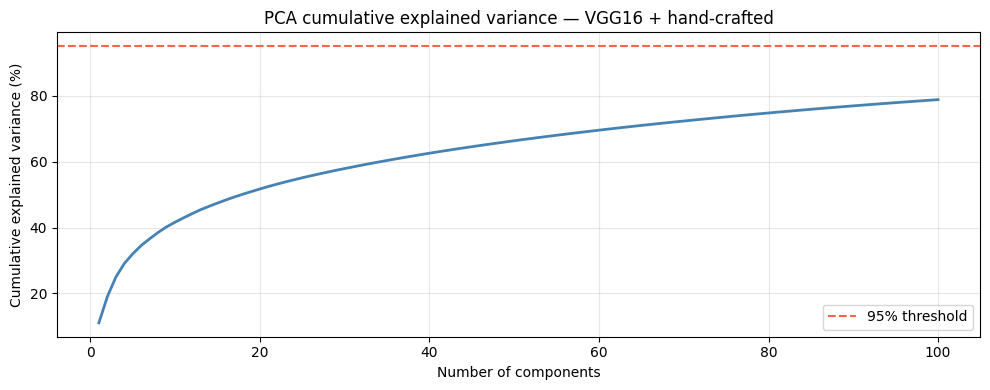

In [13]:
N_COMPONENTS = 100

reduced_sets, pca_objects = {}, {}
for arch, fused in fused_sets.items():
    pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
    reduced_sets[arch] = pca.fit_transform(fused)
    pca_objects[arch]  = pca
    print(f'{arch}: {N_COMPONENTS} PCs explain {pca.explained_variance_ratio_.sum()*100:.1f}% variance')

# Explained variance plot (VGG16 as representative)
cumvar = np.cumsum(pca_objects['VGG16'].explained_variance_ratio_) * 100
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, N_COMPONENTS + 1), cumvar, color='steelblue', lw=2)
ax.axhline(95, color='tomato', linestyle='--', label='95% threshold')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('PCA cumulative explained variance — VGG16 + hand-crafted')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 3.8 Classification

In [14]:
classifiers = {
    'SVM':               SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=SEED),
    'Random Forest':     RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'KNN':               KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=SEED),
}
print('Classifiers:', list(classifiers.keys()))

Classifiers: ['SVM', 'Random Forest', 'KNN', 'Gradient Boosting']


In [15]:
def compute_metrics(y_true, y_pred, y_prob, classes):
    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    n  = len(classes)

    sensitivities, specificities = [], []
    for i in range(n):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP
        sensitivities.append(TP / (TP + FN + 1e-9))
        specificities.append(TN / (TN + FP + 1e-9))

    y_bin = label_binarize(y_true, classes=list(range(n)))
    try:
        auc_score = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
    except Exception:
        auc_score = float('nan')

    return {
        'Accuracy':    accuracy_score(y_true, y_pred),
        'Sensitivity': np.mean(sensitivities),
        'Specificity': np.mean(specificities),
        'Precision':   report['macro avg']['precision'],
        'Recall':      report['macro avg']['recall'],
        'F1':          report['macro avg']['f1-score'],
        'AUC-ROC':     auc_score,
        'Kappa':       cohen_kappa_score(y_true, y_pred),
    }

print('Metrics helper ready.')

Metrics helper ready.


In [16]:
# ── Train & evaluate ──────────────────────────────────────────────────────────
# FIX: classifiers dict is re-instantiated inside the loop so each
# architecture gets a fresh (unfitted) estimator — avoids cross-contamination.

from sklearn.base import clone

results = {}
for arch, X in reduced_sets.items():
    results[arch] = {}
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    # Safety: confirm multiple classes in split
    assert len(np.unique(y_train)) > 1, 'Train set has only 1 class — increase MAX_PER_CLASS'

    for clf_name, clf_template in classifiers.items():
        clf    = clone(clf_template)          # fresh copy each time
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)
        m      = compute_metrics(y_test, y_pred, y_prob, CLASSES)
        results[arch][clf_name] = {'metrics': m, 'y_test': y_test,
                                    'y_pred': y_pred, 'y_prob': y_prob}
        print(f'[{arch}] {clf_name:20s}  Acc={m["Accuracy"]:.4f}  F1={m["F1"]:.4f}  Kappa={m["Kappa"]:.4f}')

[VGG16] SVM                   Acc=0.9250  F1=0.9243  Kappa=0.9000
[VGG16] Random Forest         Acc=0.8125  F1=0.8061  Kappa=0.7500
[VGG16] KNN                   Acc=0.8000  F1=0.7832  Kappa=0.7333
[VGG16] Gradient Boosting     Acc=0.8250  F1=0.8234  Kappa=0.7667
[VGG19] SVM                   Acc=0.9250  F1=0.9250  Kappa=0.9000
[VGG19] Random Forest         Acc=0.7750  F1=0.7705  Kappa=0.7000
[VGG19] KNN                   Acc=0.7125  F1=0.6854  Kappa=0.6167
[VGG19] Gradient Boosting     Acc=0.7375  F1=0.7332  Kappa=0.6500
[ResNet50] SVM                   Acc=0.9375  F1=0.9369  Kappa=0.9167
[ResNet50] Random Forest         Acc=0.8750  F1=0.8731  Kappa=0.8333
[ResNet50] KNN                   Acc=0.7375  F1=0.7223  Kappa=0.6500
[ResNet50] Gradient Boosting     Acc=0.8063  F1=0.8031  Kappa=0.7417
[EfficientNetB0] SVM                   Acc=0.9875  F1=0.9875  Kappa=0.9833
[EfficientNetB0] Random Forest         Acc=0.9313  F1=0.9311  Kappa=0.9083
[EfficientNetB0] KNN                   Acc=0.9

## 4. Results & Discussion

In [17]:
# ── Summary results table ─────────────────────────────────────────────────────
rows = []
for arch, clf_results in results.items():
    for clf_name, data in clf_results.items():
        row = {'Architecture': arch, 'Classifier': clf_name}
        row.update({k: round(v, 4) for k, v in data['metrics'].items()})
        rows.append(row)

df_results = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('\n=== Full Results Table ===\n')
print(df_results.to_string(index=False))


=== Full Results Table ===

  Architecture        Classifier  Accuracy  Sensitivity  Specificity  Precision  Recall     F1  AUC-ROC  Kappa
EfficientNetB0               SVM    0.9875       0.9875       0.9958     0.9881  0.9875 0.9875   0.9999 0.9833
      ResNet50               SVM    0.9375       0.9375       0.9792     0.9384  0.9375 0.9369   0.9929 0.9167
EfficientNetB0               KNN    0.9375       0.9375       0.9792     0.9414  0.9375 0.9357   0.9943 0.9167
EfficientNetB0     Random Forest    0.9313       0.9312       0.9771     0.9334  0.9313 0.9311   0.9912 0.9083
         VGG16               SVM    0.9250       0.9250       0.9750     0.9253  0.9250 0.9243   0.9870 0.9000
         VGG19               SVM    0.9250       0.9250       0.9750     0.9262  0.9250 0.9250   0.9845 0.9000
EfficientNetB0 Gradient Boosting    0.9125       0.9125       0.9708     0.9167  0.9125 0.9134   0.9899 0.8833
      ResNet50     Random Forest    0.8750       0.8750       0.9583     0.8739  0.

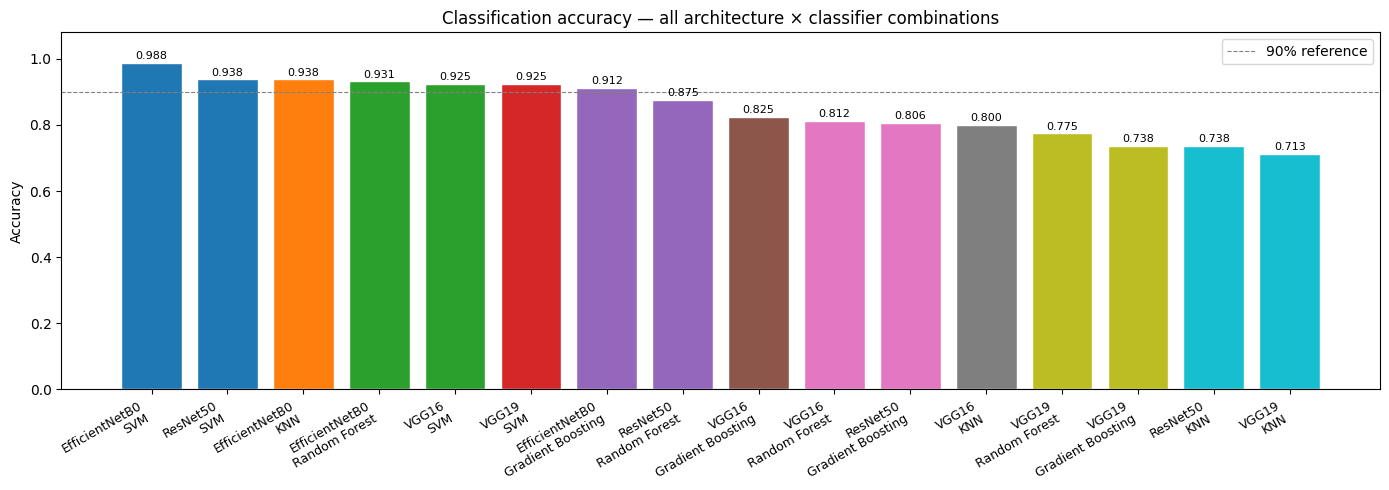

In [18]:
# ── Accuracy bar chart ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
x    = np.arange(len(df_results))
bars = ax.bar(x, df_results['Accuracy'],
              color=plt.cm.tab10(x / max(len(x)-1, 1)), edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r['Architecture']}\n{r['Classifier']}" for _, r in df_results.iterrows()],
    rotation=30, ha='right', fontsize=9
)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.08)
ax.set_title('Classification accuracy — all architecture × classifier combinations')
ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, label='90% reference')
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

Best model: EfficientNetB0 + SVM  |  Accuracy: 0.9875


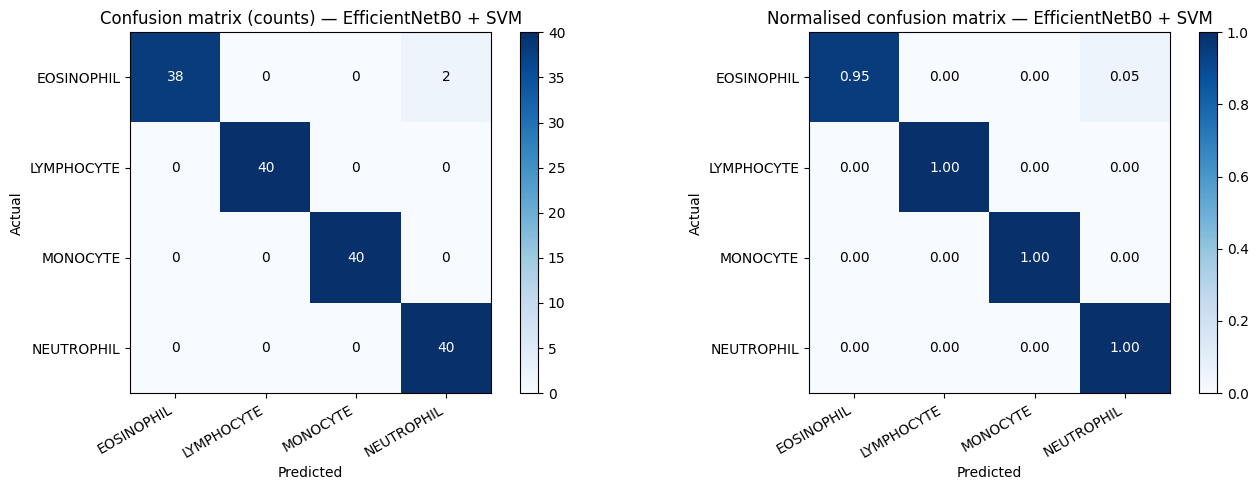

In [19]:
# ── Confusion matrices (counts + normalised) for best model ──────────────────
best_row  = df_results.iloc[0]
best_arch = best_row['Architecture']
best_clf  = best_row['Classifier']
best_data = results[best_arch][best_clf]
print(f'Best model: {best_arch} + {best_clf}  |  Accuracy: {best_row["Accuracy"]:.4f}')

cm      = confusion_matrix(best_data['y_test'], best_data['y_pred'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    [f'Confusion matrix (counts) — {best_arch} + {best_clf}',
     f'Normalised confusion matrix — {best_arch} + {best_clf}'],
    ['d', '.2f']
):
    im = ax.imshow(data, cmap='Blues')
    ax.set_xticks(range(len(CLASSES))); ax.set_yticks(range(len(CLASSES)))
    ax.set_xticklabels(CLASSES, rotation=30, ha='right')
    ax.set_yticklabels(CLASSES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(title)
    for i, j in itertools.product(range(len(CLASSES)), range(len(CLASSES))):
        ax.text(j, i, format(data[i, j], fmt), ha='center', va='center',
                color='white' if data[i, j] > data.max() / 2 else 'black', fontsize=10)
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

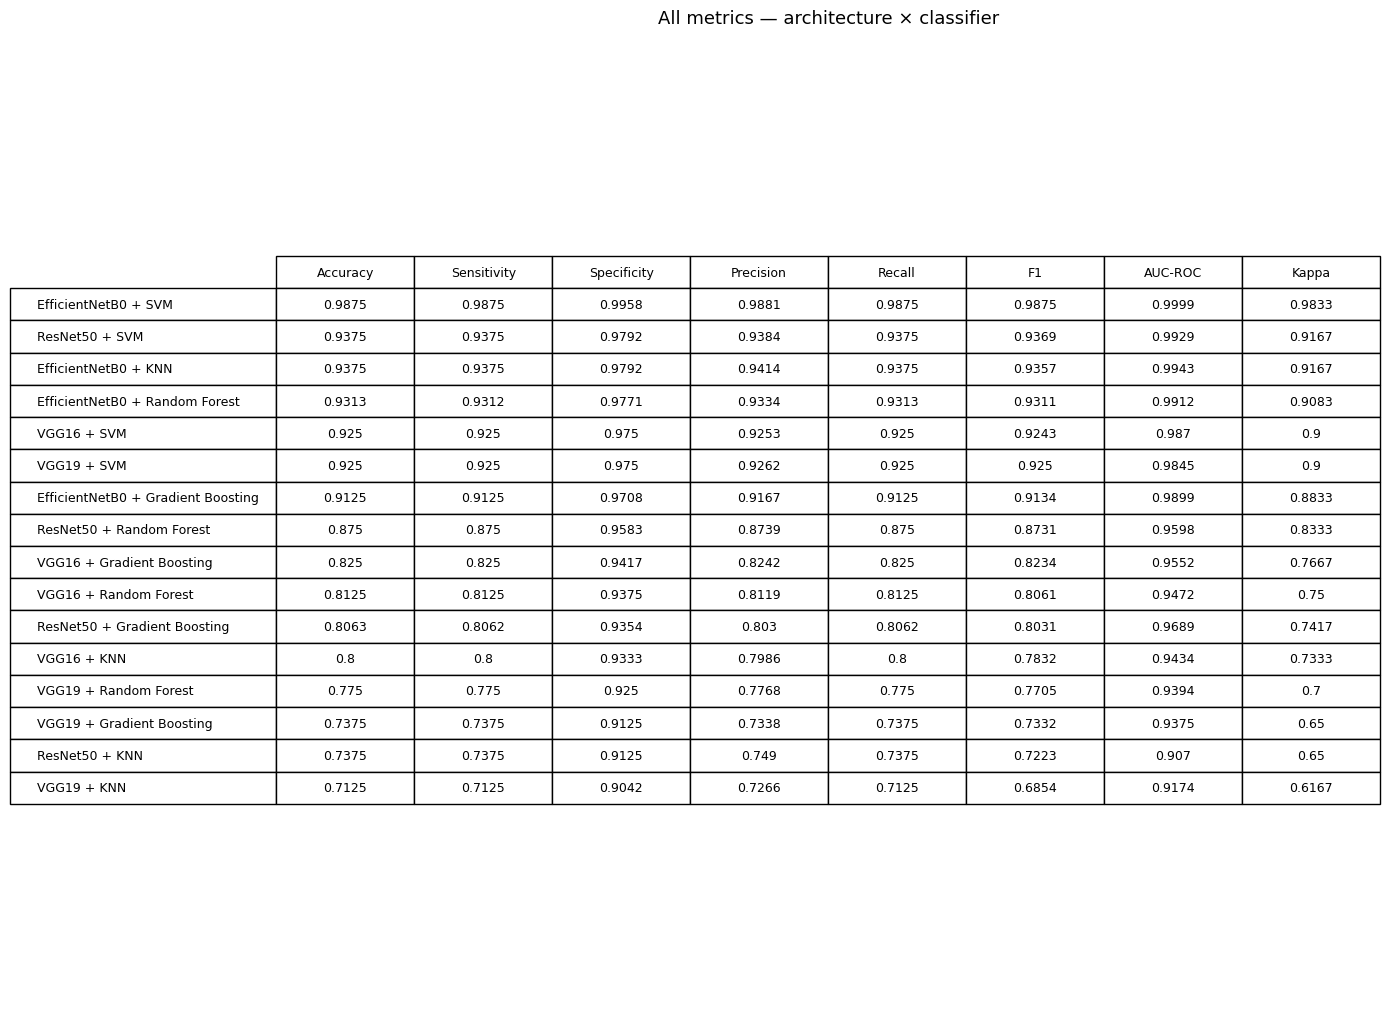


>>> Best model: EfficientNetB0 + SVM
   Accuracy    : 0.9875
   Sensitivity : 0.9875
   Specificity : 0.9958
   Precision   : 0.9881
   Recall      : 0.9875
   F1          : 0.9875
   AUC-ROC     : 0.9999
   Kappa       : 0.9833


In [20]:
# ── Full metrics table ────────────────────────────────────────────────────────
metric_cols = ['Accuracy','Sensitivity','Specificity','Precision','Recall','F1','AUC-ROC','Kappa']
pivot = df_results.set_index(['Architecture','Classifier'])[metric_cols]

fig, ax = plt.subplots(figsize=(14, len(pivot)*0.55 + 1.5))
ax.axis('off')
tbl = ax.table(
    cellText   = pivot.values.round(4),
    rowLabels  = [f'{a} + {c}' for a,c in pivot.index],
    colLabels  = metric_cols,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.6)
ax.set_title('All metrics — architecture × classifier', fontsize=13, pad=20)
plt.tight_layout(); plt.show()

print('\n>>> Best model:', best_arch, '+', best_clf)
for m, v in best_row[metric_cols].items():
    print(f'   {m:12s}: {v:.4f}')

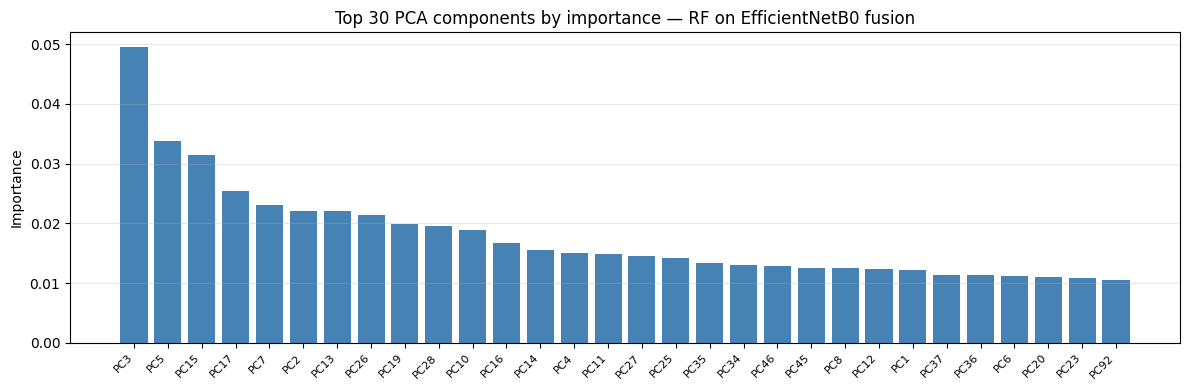

In [21]:
# ── Feature importance (Random Forest on best fused set) ──────────────────────
from sklearn.base import clone
X_best = reduced_sets[best_arch]
X_tr, X_te, y_tr, y_te = train_test_split(X_best, y, test_size=0.2, random_state=SEED, stratify=y)
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_tr, y_tr)

top_n  = 30
imp    = rf.feature_importances_
top_idx = np.argsort(imp)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(top_n), imp[top_idx], color='steelblue')
ax.set_xticks(range(top_n))
ax.set_xticklabels([f'PC{i+1}' for i in top_idx], rotation=45, ha='right', fontsize=8)
ax.set_title(f'Top {top_n} PCA components by importance — RF on {best_arch} fusion')
ax.set_ylabel('Importance'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

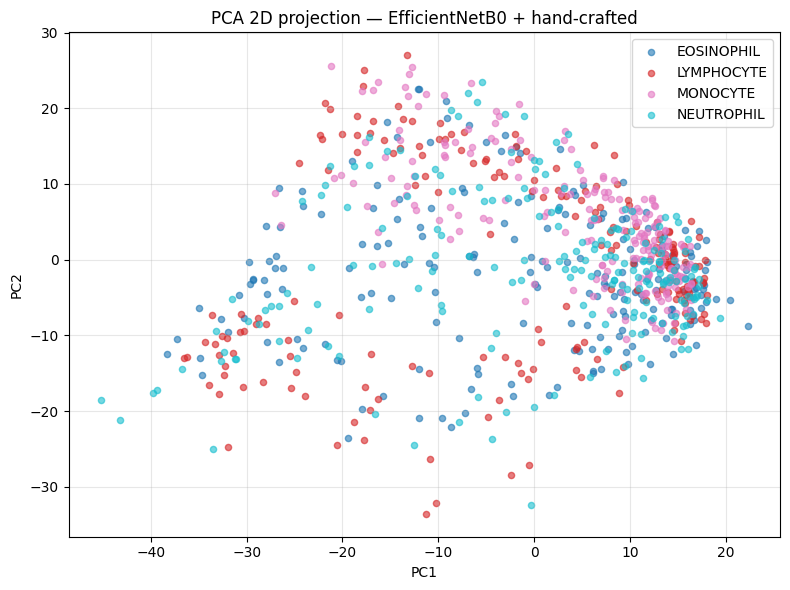

In [22]:
# ── PCA 2D scatter ────────────────────────────────────────────────────────────
pca2 = PCA(n_components=2, random_state=SEED)
X_2d = pca2.fit_transform(StandardScaler().fit_transform(fused_sets[best_arch]))

fig, ax = plt.subplots(figsize=(8, 6))
colors  = plt.cm.tab10(np.linspace(0, 1, len(CLASSES)))
for i, (cls, col) in enumerate(zip(CLASSES, colors)):
    mask = y == i
    ax.scatter(X_2d[mask,0], X_2d[mask,1], c=[col], label=cls, alpha=0.6, s=20)
ax.set_title(f'PCA 2D projection — {best_arch} + hand-crafted')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()